In [1]:
#import libraries

import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt



In [2]:
#load data
NOAA_SFO_df = pd.read_parquet(
    "../Data_Preprocessing/data/NOAA_SFO_2022_2026_cleaned.parquet"
)

NOAA_SFO_df.head()

,STATION,Station_name,DATE,Year,Month,Day,Hour,Minute,LATITUDE,LONGITUDE,...,precipitation_6_hour_Source_Station_ID,precipitation_24_hour,precipitation_24_hour_Quality_Code,precipitation_24_hour_Report_Type,precipitation_24_hour_Source_Code,precipitation_24_hour_Source_Station_ID,REM,REM_Report_Type,REM_Source_Code,REM_Source_Station_ID
0,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 00:00:00,2022,1,1,0,0,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,SYN08072494 32566 42915 10117 20044 30094 4012...,FM12,223,ICAO-KSFO
1,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 00:56:00,2022,1,1,0,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,MET09812/31/21 16:56:03 METAR KSFO 010056Z 300...,FM15,343,724940-23234
2,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 01:56:00,2022,1,1,1,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,MET09812/31/21 17:56:03 METAR KSFO 010156Z 300...,FM15,343,724940-23234
3,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 02:56:00,2022,1,1,2,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,MET10112/31/21 18:56:03 METAR KSFO 010256Z 290...,FM15,343,724940-23234
4,USW00023234,SAN FRANCISCO INTL AP,2022-01-01 03:56:00,2022,1,1,3,56,37.6197,-122.3656,...,NaN,NaN,NaN,NaN,NaN,NaN,MET09812/31/21 19:56:03 METAR KSFO 010356Z 310...,FM15,343,724940-23234


**Split training and test data for EDA purposes**
60/20/20 training/test/validation split. it is crucial we do not perform EDA on test and validation dataset

In [3]:
#First split:
# train = oldest 60%
# temp = most recent 40%
NOAA_train_df, NOAA_temp_df = train_test_split(
    NOAA_SFO_df,
    test_size=0.40,
    shuffle=False
)

# Second split:
# test = older half of temp, so subsequent 20%
# validation = newer half of temp, so most recent 20%
NOAA_test_df, NOAA_val_df = train_test_split(
    NOAA_temp_df,
    test_size=0.50,
    shuffle=False
)

# Check shapes
print(f"Training shape: {NOAA_train_df.shape}")
print(f"Test shape: {NOAA_test_df.shape}")
print(f"Validation shape: {NOAA_val_df.shape}")

Training shape: (53505, 220)
Test shape: (17835, 220)
Validation shape: (17836, 220)


In [4]:
#Verify split by confirming date 

print("Training date range:")
print(NOAA_train_df["DATE"].min(), "to", NOAA_train_df["DATE"].max())

print("\nTest date range:")
print(NOAA_test_df["DATE"].min(), "to", NOAA_test_df["DATE"].max())

print("\nValidation date range:")
print(NOAA_val_df["DATE"].min(), "to", NOAA_val_df["DATE"].max())

Training date range:
2022-01-01 00:00:00 to 2026-01-20 00:55:00

Test date range:
2026-01-20 00:56:00 to 2026-03-31 19:40:00

Validation date range:
2026-03-31 19:45:00 to 2026-06-09 16:56:00


**Perform EDA**

Temperature by Date Distribution

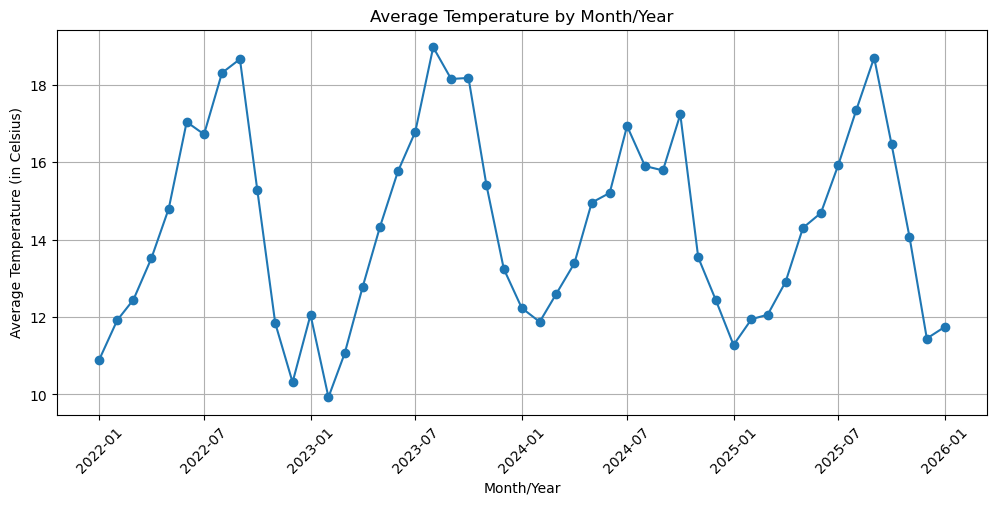

In [5]:
#Distribution plots of weather information

#conversion to datetime

# Create month/year bin
NOAA_train_df["Month_Year"] = NOAA_train_df["DATE"].dt.to_period("M")

# Calculate monthly average temperature
monthly_temp = NOAA_train_df.groupby("Month_Year")["temperature"].mean().reset_index()

# Convert Month_Year back to timestamp for plotting
monthly_temp["Month_Year"] = monthly_temp["Month_Year"].dt.to_timestamp()

#Temperature distribution
plt.figure(figsize=(12, 5))
plt.plot(monthly_temp["Month_Year"], monthly_temp["temperature"], marker="o")

plt.xlabel("Month/Year")
plt.ylabel("Average Temperature (in Celsius)")
plt.title("Average Temperature by Month/Year")
plt.xticks(rotation=45)
plt.grid()
plt.show()